<a href="https://colab.research.google.com/github/AdinaGo/AI-model-agent/blob/main/model/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# שלב 1 – תרגום הבעיה העסקית לבעיה טכנית

## הבעיה העסקית

החברה מקבלת כמות גדולה של פניות מלקוחות, וכיום נציגי השירות ממיינים ועונים עליהן באופן ידני. תהליך זה גורם לזמני תגובה ארוכים ולחוסר אחידות במענה ללקוחות.

## המטרה הטכנית

המטרה היא לבנות מערכת סיווג טקסט רב־קטגורית (Multi-Class Classification) אשר תזהה באופן אוטומטי את נושא הפנייה ותנתב אותה לתהליך הטיפול המתאים.

## משימת למידת המכונה

מדובר במשימת סיווג טקסט מונחית (Supervised Multi-Class Text Classification).

קלט:
טקסט של פנייה מלקוח.

פלט:
קטגוריית הפנייה, כגון:

* כרטיסים (Cards)
* תשלומים (Payments)
* העברות (Transfers)
* המרות מטבע (Exchange)
* משיכות מזומן (Cash ATM)
* ניהול חשבון (Account)
* אבטחה (Security)

## מדדי הערכה

מדד ה־Accuracy חשוב, אך אינו מספיק לבדו, משום שישנן קטגוריות בעלות חשיבות גבוהה יותר מאחרות.

לדוגמה, טעות בסיווג פנייה הקשורה לאבטחת חשבון עלולה להיות קריטית, גם אם רמת הדיוק הכוללת של המערכת גבוהה.

לכן בפרויקט נעשה שימוש במדדים הבאים:

* Accuracy
* Precision
* Recall
* Weighted F1-Score

מדד ה־Weighted F1-Score חשוב במיוחד משום שהוא משלב בין Precision ו־Recall תוך התחשבות בהתפלגות הקטגוריות בדאטה.

## קריטריוני הצלחה (MVP)

המערכת תיחשב מוצלחת אם:

* תשיג ערך גבוה של Weighted F1-Score.
* תסווג פניות לקוחות באופן אוטומטי.
* תנתב כל פנייה למדיניות הטיפול המתאימה.
* תייצר טיוטת תשובה מנומסת ורלוונטית ללקוח באמצעות הסוכן.


In [ ]:
!pip install -U \
"datasets==2.21.0" \
"huggingface_hub==0.36.0" \
"transformers==4.44.2" \
"sentence-transformers==3.0.1" \
"fsspec==2024.6.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
  

### טעינת מאגר הנתונים

בשלב הראשון של הפרויקט נטען מאגר הנתונים Banking77 באמצעות ספריית Hugging Face Datasets. מאגר זה מכיל אלפי פניות של לקוחות בתחום הבנקאות, כאשר לכל פנייה משויכת קטגוריה המייצגת את נושא הפנייה.

הפונקציה `load_dataset()` מורידה את הנתונים ומחלקת אותם באופן אוטומטי לקבוצות שונות, כגון קבוצת אימון (Train) וקבוצת בדיקה (Test). הצגת מבנה הנתונים מאפשרת לוודא שהטעינה בוצעה בהצלחה ולהכיר את מבנה הדאטה לפני תחילת תהליך הניתוח והמודלים.

מאגר נתונים זה ישמש אותנו לאורך כל הפרויקט לצורך ניתוח הנתונים, עיבוד הטקסט, אימון המודלים, הערכת הביצועים ובניית הסוכן החכם.


In [ ]:
from datasets import load_dataset

raw_datasets = load_dataset("banking77")
print(raw_datasets)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


הקוד יוצר טבלת DataFrame של פנדס מתוך נתוני האימון (train) שבמערך הנתונים. לאחר מכן, הפקודה head() מציגה את חמש השורות הראשונות בטבלה כדי לבדוק שהנתונים נטענו בצורה תקינה ולהתרשם מהמבנה של העמודות והמידע שמופיע בכל רשומה.

In [ ]:
import pandas as pd

df = pd.DataFrame(raw_datasets["train"])
df.head()

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10003 non-null  object
 1   label   10003 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


### יצירת קטגוריות ראשיות

מאגר הנתונים Banking77 מכיל עשרות קטגוריות מפורטות המתארות סוגים שונים של פניות לקוחות. בשלב זה יצרנו טבלת נתונים (DataFrame) מתוך קבוצת האימון והמרנו את מזהי הקטגוריות המספריים לשמות הקטגוריות המקוריים לצורך עבודה נוחה וברורה יותר.

לאחר מכן בוצע מיפוי של הקטגוריות המפורטות למספר קטגוריות ראשיות ורחבות יותר, כגון: כרטיסים, תשלומים, העברות, המרות מטבע, משיכות מזומן, ניהול חשבון ואבטחה. מטרת המיפוי היא לצמצם את מורכבות הבעיה ולהתמקד בנושאים העסקיים המרכזיים שבהם המערכת נדרשת לטפל.

בסיום התהליך נשמרו רק הרשומות ששויכו בהצלחה לאחת מהקטגוריות הראשיות, ונבדקה התפלגות הקטגוריות החדשה. שלב זה מאפשר לבצע בהמשך ניתוח נתונים, אימון מודלים והערכת ביצועים בצורה פשוטה וברורה יותר.


In [ ]:
df = pd.DataFrame(raw_datasets["train"])

label_names = raw_datasets["train"].features["label"].names
df["label_name"] = df["label"].apply(lambda x: label_names[x])

category_mapping = {
    # cards
    "activate_my_card": "cards",
    "card_arrival": "cards",
    "card_linking": "cards",
    "cash_withdrawal_card": "cards",
    "card_not_received": "cards",

    # payments
    "apple_pay_or_google_pay": "payments",
    "declined_card_payment": "payments",
    "beneficiary_not_allowed": "payments",

    # transfers
    "beneficiary_not_defined": "transfers",
    "beneficiary_not_visible": "transfers",
    "declined_transfer": "transfers",
    "transfer_not_received": "transfers",
    "cancel_transfer": "transfers",
    "pending_transfer": "transfers",

    # exchange
    "exchange_fee": "exchange",
    "exchange_rate": "exchange",
    "fiat_currency_support": "exchange",

    # cash / atm
    "cash_withdrawal": "cash_atm",
    "pending_cash_withdrawal": "cash_atm",
    "cash_withdrawal_charge": "cash_atm",
    "atm_support": "cash_atm",

    # account / security
    "edit_personal_details": "account",
    "beneficiary_not_allowed": "account",
    "change_pin": "security",
    "verify_my_identity": "security"
}

df["main_category"] = df["label_name"].map(category_mapping)

# keep only mapped categories
df = df[df["main_category"].notna()].copy()

print("Number of original labels:", df["label_name"].nunique())
print("\nMain categories distribution:")
print(df["main_category"].value_counts())

df.head()

Number of original labels: 17

Main categories distribution:
main_category
cards        451
transfers    438
cash_atm     407
payments     279
account      277
exchange     238
security     226
Name: count, dtype: int64


,text,label,label_name,main_category
0,I am still waiting on my card?,11,card_arrival,cards
1,What can I do if my card still hasn't arrived ...,11,card_arrival,cards
2,I have been waiting over a week. Is the card s...,11,card_arrival,cards
3,Can I track my card while it is in the process...,11,card_arrival,cards
4,"How do I know if I will get my card, or if it ...",11,card_arrival,cards


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

### ניתוח התפלגות הקטגוריות

בשלב זה נבדקה התפלגות הקטגוריות הראשיות במאגר הנתונים. הגרף מציג את האחוז היחסי של כל קטגוריה מתוך כלל הדוגמאות לאחר תהליך המיפוי שבוצע בשלב הקודם.

מטרת הניתוח היא לזהות האם קיימת חוסר איזון (Class Imbalance) בין הקטגוריות. כאשר קטגוריה מסוימת מיוצגת בכמות גדולה משמעותית לעומת אחרות, המודל עלול לפתח הטיה כלפיה ולהציג ביצועים נמוכים יותר עבור קטגוריות נדירות.

בחינת ההתפלגות מאפשרת להבין טוב יותר את מבנה הנתונים ולהחליט האם יש צורך בטכניקות נוספות להתמודדות עם חוסר איזון. בנוסף, ניתוח זה מספק תמונה ראשונית של סוגי הפניות הנפוצים ביותר בקרב הלקוחות.


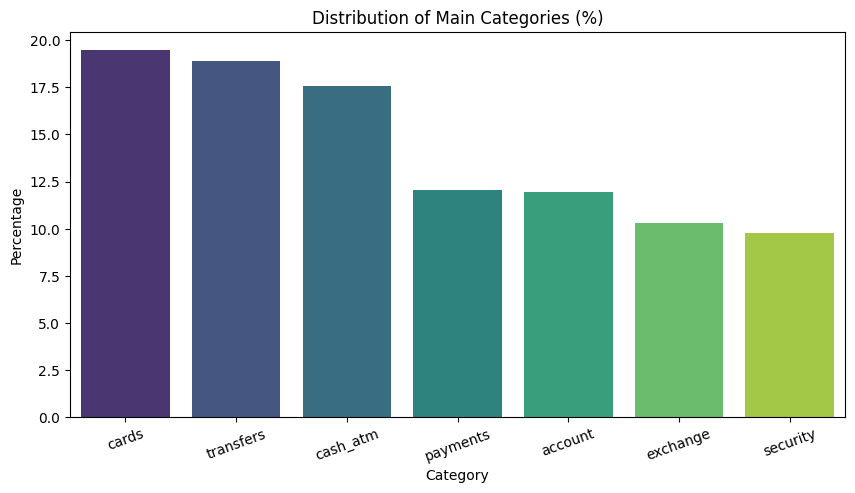

In [ ]:
category_probs = df["main_category"].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_probs.index,
    y=category_probs.values,
    hue=category_probs.index,
    palette="viridis",
    legend=False
)

plt.title("Distribution of Main Categories (%)")
plt.ylabel("Percentage")
plt.xlabel("Category")
plt.xticks(rotation=20)
plt.show()

### ניתוח המילים הנפוצות בכל קטגוריה

בשלב זה נבחנו המילים הנפוצות ביותר בכל אחת מהקטגוריות המרכזיות במאגר הנתונים. לצורך הניתוח הוסרו סימני פיסוק, הומרו כל האותיות לאותיות קטנות, והוסרו מילות עצירה (Stop Words) נפוצות שאינן תורמות להבנת תוכן הפנייה.

עבור כל קטגוריה חושבה שכיחות המילים, ולאחר מכן הוצגו המילים הנפוצות ביותר בגרף. מטרת הניתוח היא לזהות אילו מושגים ומונחים מאפיינים כל סוג של פנייה ולבחון האם קיימים הבדלים ברורים בין הקטגוריות.

ניתוח זה מספק הבנה טובה יותר של תוכן הנתונים ומסייע לוודא שהקטגוריות אכן נבדלות זו מזו מבחינה לשונית. בנוסף, הוא מאפשר לקבל אינטואיציה לגבי המילים שעליהן המודלים עשויים להסתמך במהלך תהליך הסיווג.


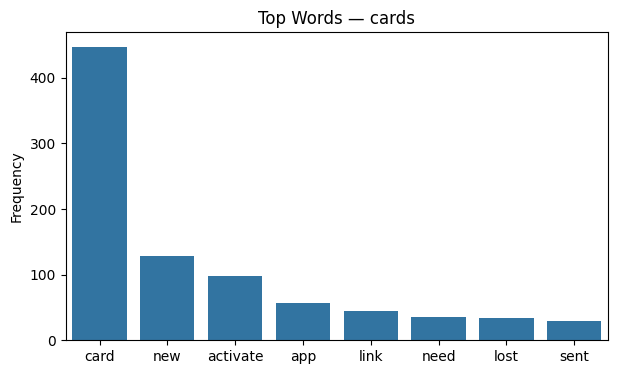

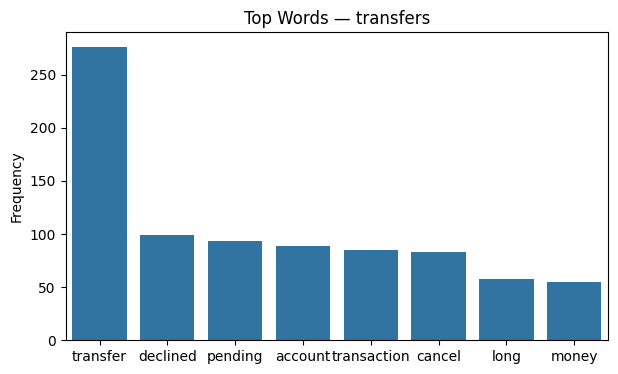

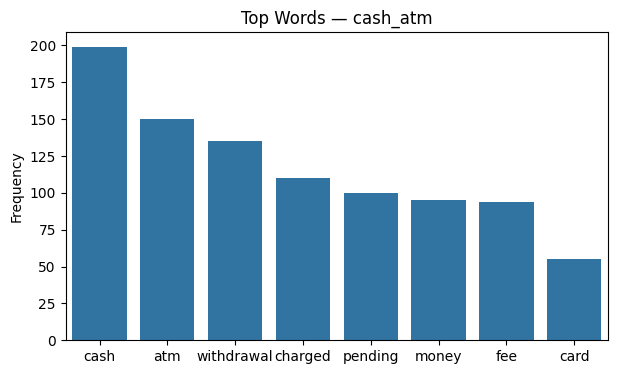

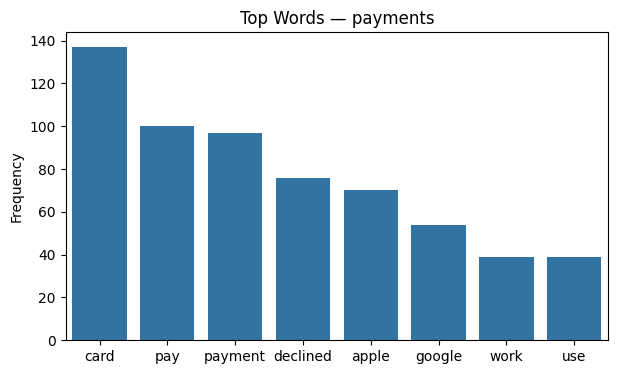

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import re

top_categories = df["main_category"].value_counts().head(4).index.tolist()

for category in top_categories:
    subset = df[df["main_category"] == category]

    words = []

    for text in subset["text"]:
        text = text.lower()
        text = re.sub(r"[^a-z\s]", " ", text)

        words.extend([
            w for w in text.split()
            if w not in ENGLISH_STOP_WORDS and len(w) > 2
        ])

    common_words = Counter(words).most_common(8)

    plt.figure(figsize=(7, 4))
    sns.barplot(
        x=[x[0] for x in common_words],
        y=[x[1] for x in common_words]
    )

    plt.title(f"Top Words — {category}")
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.show()

### ניתוח אורך הפניות לפי קטגוריה

בשלב זה נבדק אורך הפניות בכל אחת מהקטגוריות המרכזיות במאגר הנתונים. עבור כל פנייה חושב מספר המילים שהיא מכילה, ולאחר מכן הוצג Box Plot המתאר את התפלגות אורכי הטקסטים בכל קטגוריה.

מטרת הניתוח היא לבחון האם קיימים הבדלים משמעותיים באורך הפניות בין סוגי הפניות השונים. לדוגמה, ייתכן שפניות הקשורות לאבטחה או לבעיות בחשבון יכילו הסברים מפורטים יותר, בעוד שפניות אחרות יהיו קצרות ותמציתיות יותר.

הבנת התפלגות אורכי הטקסטים מסייעת להכיר טוב יותר את מאפייני הנתונים ולזהות חריגות או פערים בין הקטגוריות. בנוסף, מידע זה עשוי להשפיע על בחירת שיטות העיבוד והמודלים שבהם נשתמש בשלבים הבאים של הפרויקט.


/tmp/ipykernel_3258/416801135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


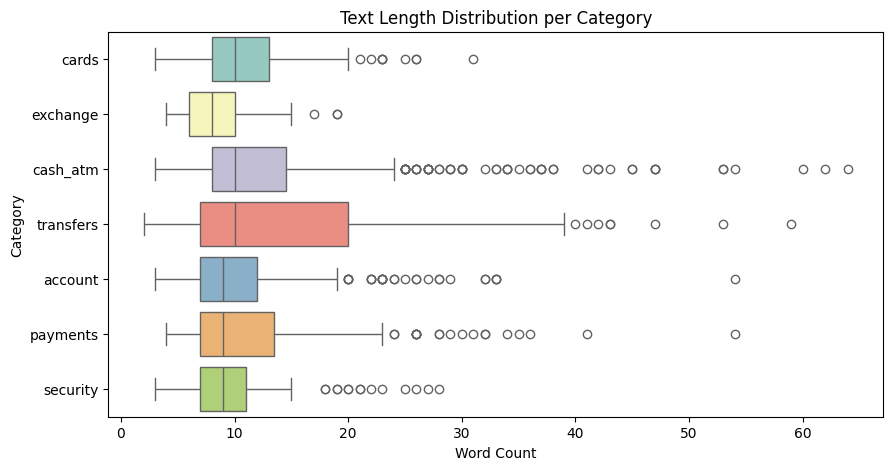

In [ ]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="word_count",
    y="main_category",
    data=df,
    palette="Set3"
)

plt.title("Text Length Distribution per Category")
plt.xlabel("Word Count")
plt.ylabel("Category")
plt.show()

### התפלגות אורכי הפניות במאגר הנתונים

בשלב זה נבחנה התפלגות אורכי הפניות בכלל מאגר הנתונים. עבור כל פנייה חושב מספר המילים שהיא מכילה, ולאחר מכן הוצג גרף היסטוגרמה המציג את שכיחות אורכי הטקסטים השונים.

מטרת הניתוח היא להבין כיצד מתפלגים אורכי הפניות ולזהות האם רוב הפניות קצרות, ארוכות או מרוכזות בטווח מסוים. בנוסף, הגרף מאפשר לזהות פניות חריגות בעלות אורך יוצא דופן, אשר עשויות להשפיע על תהליך האימון של המודלים.

הבנת התפלגות אורכי הטקסטים מספקת תמונה כללית על מאפייני הדאטה ומסייעת בבחירת שיטות עיבוד מתאימות. מידע זה חשוב במיוחד בפרויקטי NLP, שכן אורך הטקסט עשוי להשפיע על איכות הייצוג של הנתונים ועל ביצועי המודלים בשלבים הבאים.


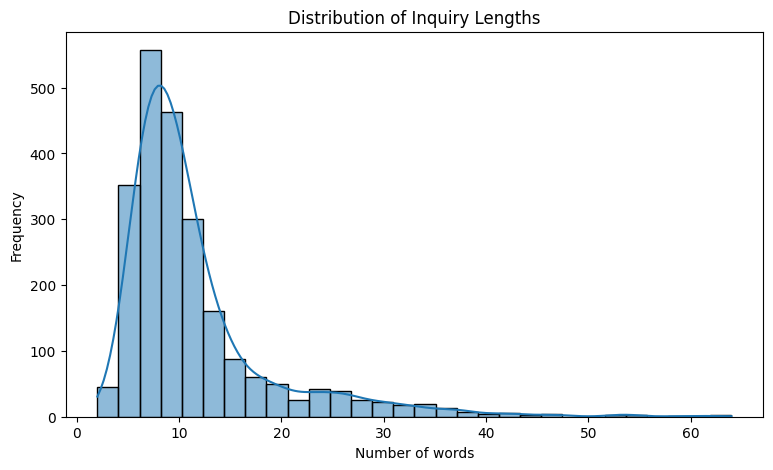

In [ ]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    kde=True
)

plt.title("Distribution of Inquiry Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")

plt.show()

### עיבוד מקדים של הטקסט (Preprocessing)

לפני אימון המודלים בוצע תהליך עיבוד מקדים (Preprocessing) לטקסטים במטרה לנקות את הנתונים ולהפוך אותם לייצוג אחיד ואיכותי יותר.

בשלב זה כל הטקסטים הומרו לאותיות קטנות (Lowercase) כדי למנוע מצב שבו אותה מילה תיחשב למילים שונות רק בגלל הבדלי אותיות גדולות וקטנות. בנוסף, הוסרו סימנים מיוחדים, מספרים ותווי פיסוק שאינם תורמים להבנת משמעות הפנייה.

לאחר מכן הוסרו מילות עצירה (Stop Words) נפוצות בשפה האנגלית, כגון "the", "and" ו-"is", מכיוון שהן מופיעות בתדירות גבוהה אך אינן מוסיפות מידע משמעותי לצורך הסיווג.

לבסוף בוצע Lemmatization, תהליך שבו מילים שונות בעלות אותה משמעות בסיסית מומרות לצורת השורש שלהן. לדוגמה, המילים "payments", "paying" ו-"paid" יכולות להיות מיוצגות בצורה אחידה יותר. פעולה זו מסייעת לצמצם את גודל אוצר המילים ומשפרת את יכולת המודל לזהות קשרים בין פניות דומות.

בסיום התהליך נוצרה עמודה חדשה המכילה את הטקסט המעובד, אשר תשמש בשלבים הבאים ליצירת ייצוגים מספריים ולאימון מודלי הסיווג.


In [ ]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["cleaned_text"] = df["text"].apply(preprocess_text)

print("Preprocessing complete.")
display(df[["text", "cleaned_text"]].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Preprocessing complete.


,text,cleaned_text
0,I am still waiting on my card?,still waiting card
1,What can I do if my card still hasn't arrived ...,card still arrived week
2,I have been waiting over a week. Is the card s...,waiting week card still coming
3,Can I track my card while it is in the process...,track card process delivery
4,"How do I know if I will get my card, or if it ...",know get card lost


### בדיקת איכות תהליך הניקוי

לאחר השלמת תהליך ה־Preprocessing בוצעה בדיקת תקינות במטרה לוודא שהניקוי לא גרם לאובדן מידע משמעותי. במסגרת הבדיקה נספרו פניות שהפכו לריקות לחלוטין לאחר הסרת סימנים מיוחדים, מילות עצירה ומילים קצרות.

בנוסף, הוצגו מספר דוגמאות אקראיות של הטקסט המקורי לצד הטקסט המעובד. השוואה זו מאפשרת לבחון באופן ידני את השפעת תהליך הניקוי ולוודא שהמידע המרכזי בפנייה נשמר, בעוד שמידע מיותר או רעש טקסטואלי הוסר.

שלב זה חשוב לצורך בקרת איכות הנתונים, מכיוון שעיבוד אגרסיבי מדי עלול להסיר מידע שימושי ולפגוע בביצועי המודל, בעוד שעיבוד מתאים משפר את איכות הייצוג של הטקסטים ומסייע למודלים ללמוד את הדפוסים הרלוונטיים בצורה יעילה יותר.


In [ ]:
empty_rows = (df["cleaned_text"] == "").sum()

print(f"Number of empty inquiries after cleaning: {empty_rows}")

display(df[["text", "cleaned_text"]].sample(3, random_state=42))

Number of empty inquiries after cleaning: 0


,text,cleaned_text
3752,I would like to edit my personal information .,would like edit personal information
881,Do you allow currency exchanges?,allow currency exchange
100,can you share card tracking number?,share card tracking number


##TF-IDF

### חלוקת הנתונים ויצירת ייצוג TF-IDF

לאחר השלמת תהליך ניקוי הטקסטים, חולק מאגר הנתונים לשתי קבוצות: קבוצת אימון (Training Set) וקבוצת בדיקה (Test Set). קבוצת האימון משמשת ללמידת המודל, בעוד שקבוצת הבדיקה משמשת להערכת ביצועיו על נתונים שלא נראו במהלך האימון.

החלוקה בוצעה באמצעות Stratified Sampling, כך שהתפלגות הקטגוריות נשמרה באופן דומה בשתי הקבוצות. גישה זו מסייעת לקבל הערכה אמינה יותר של ביצועי המודל ומונעת הטיה הנובעת מהבדלים בהתפלגות הנתונים.

לאחר מכן הומרו הטקסטים לייצוג מספרי באמצעות שיטת TF-IDF (Term Frequency – Inverse Document Frequency). שיטה זו מעניקה משקל גבוה יותר למילים שמאפיינות מסמכים מסוימים ומשקל נמוך למילים נפוצות המופיעות ברוב המסמכים.

בנוסף, נעשה שימוש ב־Unigrams וב־Bigrams, כלומר המודל מתחשב הן במילים בודדות והן בצמדי מילים סמוכות. כמו כן, סוננו מילים נדירות מאוד ומילים נפוצות מדי, במטרה לצמצם רעש ולשפר את איכות הייצוג של הטקסטים.

בסיום התהליך התקבלו מטריצות מספריות המייצגות את הטקסטים, והן ישמשו כקלט למודלי הסיווג בשלבים הבאים של הפרויקט.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# X = טקסט, y = קטגוריה ראשית
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["main_category"],
    test_size=0.2,
    random_state=42,
    stratify=df["main_category"]
)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,        # מסנן מילים שמופיעות פעם-פעמיים בלבד
    max_df=0.95      # מסנן מילים נפוצות מדי
)

X_train = tfidf_vectorizer.fit_transform(X_train_raw)
X_test = tfidf_vectorizer.transform(X_test_raw)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("TF-IDF ready ")

Train shape: (1852, 1547)
Test shape: (464, 1547)
TF-IDF ready 


##אימון מודל ה-SVM

### אימון מודל הבסיס (Baseline Model)

בשלב זה אומן מודל סיווג מסוג Support Vector Machine (SVM), אשר שימש כמודל הבסיס של הפרויקט. מודל זה נבחר מכיוון שהוא ידוע כיעיל במיוחד במשימות סיווג טקסט המבוססות על ייצוגי TF-IDF, ומספק ביצועים טובים גם כאשר מספר המאפיינים גדול מאוד.

נעשה שימוש בגרסה ליניארית של המודל (Linear Kernel), המתאימה במיוחד לבעיות סיווג טקסט, שבהן הנתונים מיוצגים במרחב בעל אלפי מאפיינים. במהלך האימון המודל למד לזהות דפוסים וקשרים בין המילים והביטויים המופיעים בפניות הלקוחות לבין הקטגוריה המתאימה לכל פנייה.

מטרת מודל זה היא לספק נקודת ייחוס (Baseline) לביצועים, אשר תשמש בהמשך להשוואה מול גישות מתקדמות יותר, כגון מודלי Transformer ו־Large Language Models. השוואה זו תאפשר להעריך האם השימוש במודלים מורכבים יותר אכן מוביל לשיפור משמעותי בביצועי הסיווג.


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Model training finished")

Model training finished


### הערכת ביצועי מודל ה־SVM

לאחר השלמת תהליך האימון, בוצעה הערכה של ביצועי מודל ה־SVM על קבוצת הבדיקה, אשר לא נחשפה למודל במהלך האימון. מטרת שלב זה היא לבדוק את יכולת ההכללה (Generalization) של המודל ואת ביצועיו על נתונים חדשים.

תחילה חושב מדד ה־Accuracy, המייצג את שיעור התחזיות הנכונות מתוך כלל התחזיות שביצע המודל. לאחר מכן הופק דוח סיווג (Classification Report), המציג עבור כל קטגוריה את מדדי ה־Precision, Recall ו־F1-Score.

מדדים אלו מספקים תמונה מפורטת יותר של ביצועי המודל:

* Precision בודק עד כמה התחזיות של המודל עבור קטגוריה מסוימת היו נכונות.
* Recall בודק עד כמה המודל הצליח לזהות את כל הדוגמאות השייכות לאותה קטגוריה.
* F1-Score משלב בין Precision ו־Recall למדד אחד מאוזן.

ניתוח המדדים מאפשר לזהות קטגוריות שבהן המודל מצטיין לצד קטגוריות מאתגרות יותר, ומהווה בסיס להשוואה מול המודלים המתקדמים שיופעלו בהמשך הפרויקט.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9698275862068966
              precision    recall  f1-score   support

     account       0.94      0.91      0.93        55
       cards       0.99      1.00      0.99        90
    cash_atm       0.96      1.00      0.98        82
    exchange       1.00      0.96      0.98        48
    payments       0.93      0.98      0.96        56
    security       1.00      1.00      1.00        45
   transfers       0.96      0.93      0.95        88

    accuracy                           0.97       464
   macro avg       0.97      0.97      0.97       464
weighted avg       0.97      0.97      0.97       464



### ניתוח מטריצת הבלבול (Confusion Matrix)

לאחר הערכת ביצועי מודל ה־SVM, נבחנה מטריצת הבלבול (Confusion Matrix) במטרה להבין בצורה מעמיקה יותר את סוגי הטעויות שהמודל מבצע.

מטריצת הבלבול מציגה את הקטגוריה האמיתית של כל פנייה מול הקטגוריה שחזה המודל. הערכים המופיעים על האלכסון הראשי מייצגים תחזיות נכונות, בעוד שערכים מחוץ לאלכסון מייצגים מקרים שבהם המודל התבלבל בין קטגוריות שונות.

באמצעות מטריצה זו ניתן לזהות אילו קטגוריות מסווגות בצורה מדויקת במיוחד ואילו קטגוריות נוטות להתבלבל זו עם זו. טעויות אלו עשויות לנבוע מדמיון סמנטי בין סוגי פניות שונים או משימוש במונחים דומים במספר קטגוריות.

ניתוח מטריצת הבלבול מספק תובנות חשובות לגבי נקודות החוזק והחולשה של המודל ומהווה כלי מרכזי להבנת התנהגות המודל מעבר למדדי הביצועים הכלליים, כגון Accuracy ו־F1-Score.


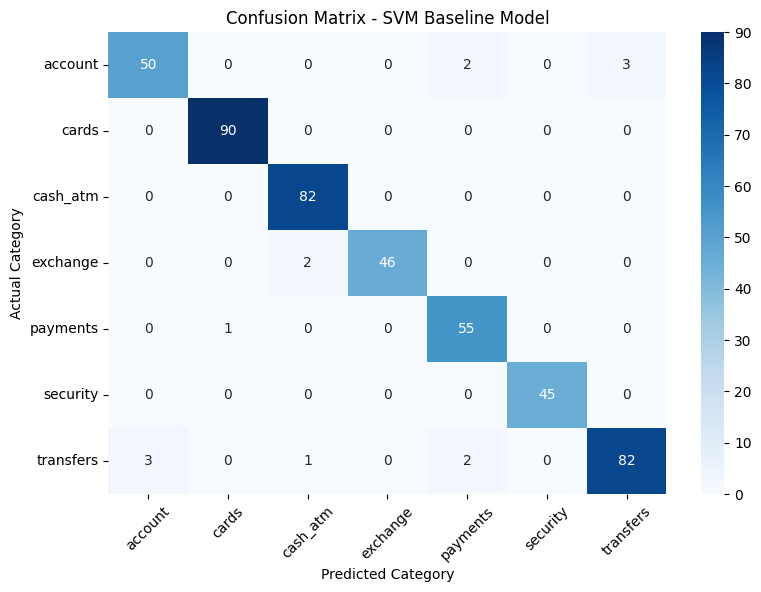

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)

plt.figure(figsize=(9, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_,
    cmap="Blues"
)

plt.title("Confusion Matrix - SVM Baseline Model")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### ניתוח תוצאות מטריצת הבלבול

מטריצת הבלבול מראה כי מודל ה־SVM הצליח לסווג בצורה מדויקת מאוד את רוב הקטגוריות. ניתן לראות כי הקטגוריות Cards, Cash ATM ו־Security סווגו כמעט ללא טעויות, דבר המעיד על כך שלקטגוריות אלו קיימים מאפייני טקסט ברורים ומובחנים.

מרבית הטעויות מופיעות בין קטגוריות בעלות קשר עסקי או סמנטי דומה. לדוגמה, חלק מפניות ה־Transfers סווגו כ־Account או Payments, וחלק מפניות ה־Account סווגו כ־Transfers. בנוסף, נצפו מספר קטן של בלבולים בין Payments ל־Cards ובין Exchange ל־Cash ATM.

ממצאים אלו מעידים כי מודל ה־SVM מצליח לזהות היטב את רוב הדפוסים בטקסט, אך במקרים שבהם קיימת חפיפה במונחים ובנושאי הפנייה נדרשת הבנה סמנטית עמוקה יותר. מסיבה זו נבחן בהמשך גם שימוש במודלים מתקדמים המבוססים על Transformer ו־Large Language Models.


In [ ]:
!pip install sentence-transformers umap-learn



### יצירת Embeddings וניתוח סמנטי

בשלב זה נעשה שימוש במודל Sentence Transformer מסוג **all-MiniLM-L6-v2** לצורך יצירת Embeddings עבור הטקסטים המעובדים. Embedding הוא ייצוג מספרי צפוף של טקסט, אשר נועד ללכוד את המשמעות הסמנטית שלו ולא רק את המילים המופיעות בו.

בניגוד לשיטות מסורתיות כגון TF-IDF, המתבססות בעיקר על שכיחות מילים, מודלי Embeddings מסוגלים לייצג קשרים סמנטיים עמוקים יותר בין משפטים וטקסטים. כתוצאה מכך, פניות בעלות משמעות דומה עשויות לקבל ייצוגים קרובים גם כאשר הן משתמשות במילים שונות.

מכיוון שה־Embeddings נוצרים במרחב בעל מאות ממדים, נעשה שימוש באלגוריתם UMAP לצורך הורדת הממדים לשני ממדים בלבד. פעולה זו מאפשרת להציג את הנתונים בצורה ויזואלית ולבחון האם פניות השייכות לאותה קטגוריה נוטות להתקבץ יחד.

בגרף המתקבל כל נקודה מייצגת פנייה אחת, והצבע מייצג את הקטגוריה שלה. אם נצפים אשכולות (Clusters) ברורים של נקודות מאותו צבע, הדבר מעיד כי מודל ה־Embeddings מצליח ללכוד את המשמעות הסמנטית של הפניות ולהבחין בין סוגי פניות שונים.

ניתוח זה מספק אינדיקציה איכותית ליכולת הייצוג של מודלי השפה המודרניים ומהווה שלב מקדים לפני בחינת מודלים מתקדמים יותר המבוססים על Transformer ו־Large Language Models.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings... This might take a minute.


Batches:   0%|          | 0/73 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


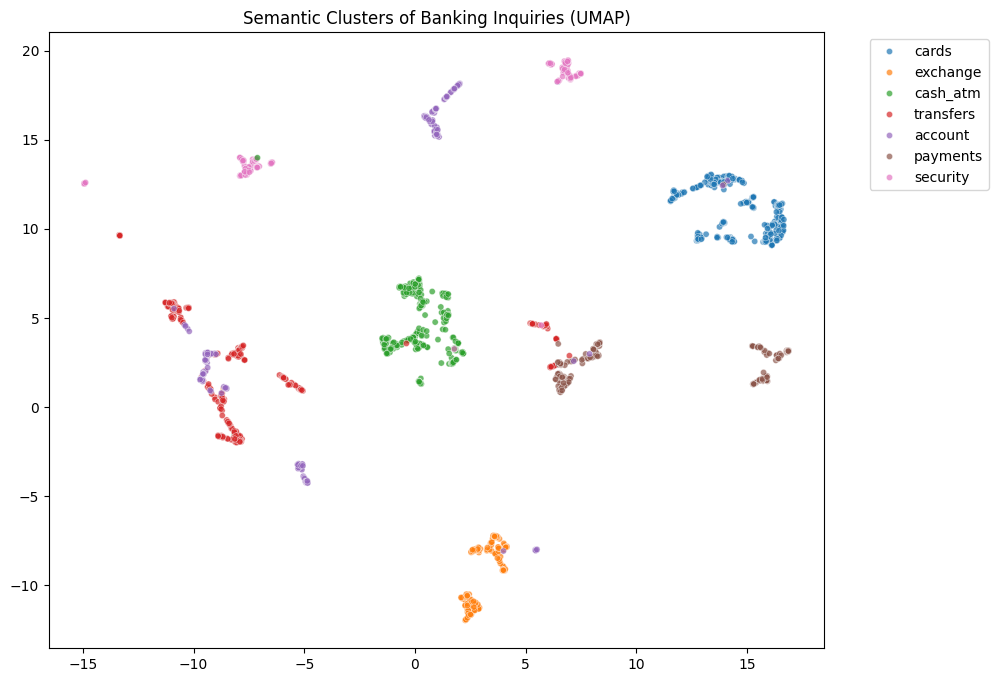

In [ ]:
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# טעינת מודל Embeddings
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# יצירת Embeddings לטקסט הנקי שלנו
print("Generating embeddings... This might take a minute.")
embeddings = embedder.encode(df['cleaned_text'].tolist(), show_progress_bar=True)

# הורדת הממדים ל-2 באמצעות UMAP לצורך ויזואליזציה
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embeddings = reducer.fit_transform(embeddings)

# ציור הגרף
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=umap_embeddings[:, 0],
    y=umap_embeddings[:, 1],
    hue=df['main_category'],
    palette='tab10',
    s=20, alpha=0.7
)
plt.title('Semantic Clusters of Banking Inquiries (UMAP)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# מסקנה מהגרף: נקודות מאותו צבע אמורות להיות קרובות זו לזו, מה שמעיד על כך שהמודל מבין את הקשר הסמנטי.

###עיבוד נתונים והכנה לאימון מודל שפה (Fine-Tuning)

### הכנת הנתונים לאימון מודל DistilBERT

בשלב זה הוכנו הנתונים לצורך אימון מודל Transformer מסוג DistilBERT. בניגוד למודל ה־SVM, שעבד על ייצוגי TF-IDF, מודל DistilBERT מקבל כקלט טוקנים מספריים ולכן יש צורך לבצע התאמה מיוחדת של הנתונים.

תחילה הומרו שמות הקטגוריות לערכים מספריים באמצעות `LabelEncoder`, מכיוון שמודלי סיווג ב־PyTorch עובדים עם תוויות מספריות ולא עם שמות טקסטואליים. לאחר מכן חולקו הנתונים לקבוצת אימון ולקבוצת ולידציה, תוך שמירה על התפלגות הקטגוריות באמצעות stratify.

בהמשך נטען ה־Tokenizer של המודל `distilbert-base-uncased`. תפקיד ה־Tokenizer הוא להמיר כל טקסט לרצף של מזהים מספריים שהמודל יכול לעבד. בנוסף, הוגדרו פעולות כמו חיתוך טקסטים ארוכים, השלמת Padding, והגבלת אורך הקלט ל־128 טוקנים.

לאחר מכן נבנתה מחלקת Dataset מותאמת אישית בשם `BankingDataset`, אשר מחזירה לכל דוגמה את הטוקנים ואת התווית המתאימה. לבסוף נוצרו DataLoaders עבור קבוצת האימון וקבוצת הוולידציה, כדי לאפשר אימון יעיל של המודל במנות קטנות (Batches).

שלב זה הוא שלב הכנה מרכזי לפני Fine-Tuning, מכיוון שהוא מתאים את הנתונים הגולמיים לפורמט הדרוש לאימון מודל Transformer.


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# הפיכת הקטגוריות למספרים (0 עד 6 לדוגמה)
label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['main_category'])
num_labels = len(label_encoder.classes_)

# חלוקה ל-Train ו-Validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['cleaned_text'].tolist(), df['label_id'].tolist(), test_size=0.2, random_state=42, stratify=df['label_id']
)

# טעינת Tokenizer של BERT (מודל קל ומהיר יחסית)
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

class BankingDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BankingDataset(train_texts, train_labels)
val_dataset = BankingDataset(val_texts, val_labels)

train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=16)
eval_dataloader = DataLoader(val_dataset, batch_size=16)
print("DataLoaders ready!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DataLoaders ready!


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### פונקציית הערכה למודל (Evaluation Function)

בשלב זה נבנתה פונקציית הערכה ייעודית שמטרתה למדוד את ביצועי מודל ה־DistilBERT במהלך תהליך האימון ולאחריו. הפונקציה מקבלת את המודל המאומן, את קבוצת הנתונים להערכה (DataLoader) ואת סביבת החישוב (CPU או GPU), ומחזירה את מדדי הביצועים המרכזיים.

תחילה המודל מועבר למצב הערכה (`eval()`), שבו הוא מפסיק לבצע פעולות המיועדות לאימון בלבד, כגון Dropout. לאחר מכן מתבצע מעבר על כל הדוגמאות בקבוצת ההערכה ללא חישוב גרדיאנטים (`torch.no_grad()`), דבר המקטין את צריכת הזיכרון ומייעל את תהליך ההערכה.

עבור כל אצווה (Batch) נאספים ערכי ה־Loss, התחזיות של המודל והתוויות האמיתיות. בסיום התהליך מחושבים שלושה מדדי ביצועים מרכזיים:

* **Loss** – מודד את מידת השגיאה של המודל.
* **Accuracy** – אחוז התחזיות הנכונות מתוך כלל התחזיות.
* **Weighted F1-Score** – מדד המשלב בין Precision ו־Recall תוך התחשבות בהתפלגות הקטגוריות.

פונקציה זו תשמש בהמשך הפרויקט לצורך מעקב אחר התקדמות המודל במהלך האימון ולהערכת יכולת ההכללה שלו על נתונים שלא נראו קודם.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            total_loss += outputs.loss.item()
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, acc, f1

### אימון מודל DistilBERT (Fine-Tuning)

בשלב זה בוצע תהליך Fine-Tuning למודל DistilBERT על מאגר פניות הלקוחות. Fine-Tuning הוא תהליך שבו לוקחים מודל שפה שאומן מראש על כמויות גדולות של טקסט, ומתאימים אותו למשימה ספציפית באמצעות אימון נוסף על הנתונים הרלוונטיים.

תחילה הוגדר מודל הסיווג והועבר לסביבת החישוב המתאימה (CPU או GPU). לאחר מכן הוגדר אופטימייזר מסוג AdamW, אשר אחראי על עדכון משקלי המודל במהלך האימון, וכן Scheduler שתפקידו להתאים באופן הדרגתי את קצב הלמידה (Learning Rate) לאורך התהליך.

האימון בוצע לאורך מספר Epochs, כאשר בכל Epoch המודל עבר על כל דוגמאות האימון, חישב את השגיאה (Loss) ועדכן את משקליו במטרה לשפר את יכולת הסיווג שלו. בסיום כל Epoch בוצעה הערכה על קבוצת הוולידציה באמצעות פונקציית ההערכה שהוגדרה קודם לכן.

במהלך האימון נשמרו מדדי הביצועים המרכזיים עבור קבוצת האימון וקבוצת הוולידציה, כולל:

* Loss
* Accuracy
* Weighted F1-Score

בנוסף, יושמה טכניקת Early Stopping לצורך מניעת אימון יתר (Overfitting). לאחר כל Epoch נבדק מדד ה־Validation F1, ובמקרה של שיפור נשמרה הגרסה הטובה ביותר של המודל. אם לא חל שיפור במשך מספר Epochs רצופים, תהליך האימון הופסק באופן אוטומטי.

בסיום האימון נטענה מחדש הגרסה בעלת ביצועי הוולידציה הטובים ביותר, כך שהמודל הסופי שנבחר הוא המודל שהציג את יכולת ההכללה הגבוהה ביותר על נתונים שלא נראו במהלך האימון.

שמירת ההיסטוריה מאפשרת לנתח את תהליך הלמידה, לעקוב אחר שיפור הביצועים לאורך הזמן ולזהות תופעות כגון Overfitting או Underfitting. נתונים אלו ישמשו בהמשך להצגת גרפי הלמידה ולהערכת איכות המודל.


In [ ]:
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm.auto import tqdm
import copy

# Initialize model
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels
)

model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)

num_epochs = 10
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": []
}

# Early Stopping settings
patience = 2
best_val_f1 = 0
best_model_state = None
epochs_without_improvement = 0

print(f"Starting training on {device}...")
progress_bar = tqdm(range(num_training_steps))

for epoch in range(num_epochs):
    model.train()

    train_preds = []
    train_labels_all = []
    epoch_train_loss = 0

    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        progress_bar.update(1)

        epoch_train_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=-1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(batch["labels"].cpu().numpy())

    t_loss = epoch_train_loss / len(train_dataloader)
    t_acc = accuracy_score(train_labels_all, train_preds)
    t_f1 = f1_score(train_labels_all, train_preds, average="weighted")

    v_loss, v_acc, v_f1 = evaluate_model(model, eval_dataloader, device)

    history["train_loss"].append(t_loss)
    history["train_accuracy"].append(t_acc)
    history["train_f1"].append(t_f1)
    history["val_loss"].append(v_loss)
    history["val_accuracy"].append(v_acc)
    history["val_f1"].append(v_f1)

    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print(f"Train - Loss: {t_loss:.4f}, Acc: {t_acc:.4f}, F1: {t_f1:.4f}")
    print(f"Val   - Loss: {v_loss:.4f}, Acc: {v_acc:.4f}, F1: {v_f1:.4f}")

    # Save best model according to validation F1
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        print("New best model saved.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    # Stop if validation F1 does not improve
    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# Load best model version
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"\nBest Validation F1: {best_val_f1:.4f}")
print("Best model loaded.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training on cuda...


  0%|          | 0/1160 [00:00<?, ?it/s]


Epoch 1/10
Train - Loss: 0.6394, Acc: 0.8418, F1: 0.8409
Val   - Loss: 0.1522, Acc: 0.9655, F1: 0.9657
New best model saved.

Epoch 2/10
Train - Loss: 0.0895, Acc: 0.9773, F1: 0.9773
Val   - Loss: 0.1161, Acc: 0.9720, F1: 0.9719
New best model saved.

Epoch 3/10
Train - Loss: 0.0424, Acc: 0.9914, F1: 0.9914
Val   - Loss: 0.1655, Acc: 0.9526, F1: 0.9522
No improvement for 1 epoch(s).

Epoch 4/10
Train - Loss: 0.0291, Acc: 0.9930, F1: 0.9930
Val   - Loss: 0.1383, Acc: 0.9655, F1: 0.9656
No improvement for 2 epoch(s).
Early stopping triggered.

Best Validation F1: 0.9719
Best model loaded.



לולאת האימון היא השלב שבו המודל לומד מהנתונים ומשפר את הביצועים שלו.

בכל **Epoch** המודל עובר על כל נתוני האימון (**Train Data**), המחולקים ל־**Batches**.

בכל **Batch** מתבצעים השלבים הבאים:

- העברת הנתונים ל־CPU או ל־GPU.
- שליחת הנתונים למודל.
- קבלת תחזיות וערך **Loss**.
- חישוב הגרדיאנטים באמצעות `loss.backward()`.
- עדכון משקלי המודל באמצעות `optimizer.step()`.
- עדכון קצב הלמידה באמצעות `lr_scheduler.step()`.
- ניקוי הגרדיאנטים באמצעות `optimizer.zero_grad()`.
- שמירת התחזיות לצורך חישוב מדדי ביצוע.

בסיום כל **Epoch** חישבתי:

- **Train Loss** – ממוצע השגיאה של המודל.
- **Train Accuracy** – אחוז התחזיות הנכונות.
- **Train F1 Score** – מדד המשלב בין Precision ל־Recall.

לאחר מכן הרצתי **Evaluation** על סט ה־Validation כדי לבדוק כיצד המודל מתפקד על נתונים שלא ראה במהלך האימון.

###שמירת המודל המאומן
בסיום תהליך האימון נשמרו המודל וה־Tokenizer לדיסק. פעולה זו מאפשרת לטעון את המודל בשלב מאוחר יותר ללא צורך באימון מחדש, ולהשתמש בו כחלק מסוכן הבינה המלאכותית שפותח בפרויקט.

In [ ]:
# Save label mapping inside the model config
model.config.id2label = {
    0: "account",
    1: "cards",
    2: "cash_atm",
    3: "exchange",
    4: "payments",
    5: "security",
    6: "transfers"
}

model.config.label2id = {
    "account": 0,
    "cards": 1,
    "cash_atm": 2,
    "exchange": 3,
    "payments": 4,
    "security": 5,
    "transfers": 6
}

model_save_path = "banking77_distilbert_best_model"

model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print("Best DistilBERT model and tokenizer saved successfully.")

Best DistilBERT model and tokenizer saved successfully.


In [ ]:
!zip -r banking77_distilbert_best_model.zip banking77_distilbert_best_model

  adding: banking77_distilbert_best_model/ (stored 0%)
  adding: banking77_distilbert_best_model/config.json (deflated 52%)
  adding: banking77_distilbert_best_model/tokenizer_config.json (deflated 76%)
  adding: banking77_distilbert_best_model/special_tokens_map.json (deflated 42%)
  adding: banking77_distilbert_best_model/tokenizer.json (deflated 71%)
  adding: banking77_distilbert_best_model/model.safetensors (deflated 8%)
  adding: banking77_distilbert_best_model/vocab.txt (deflated 53%)


### ניתוח תהליך הלמידה (Learning Curves)

בשלב זה הוצגו גרפים המתארים את התפתחות ביצועי מודל ה־DistilBERT לאורך תהליך האימון. עבור כל Epoch נשמרו מדדי הביצועים של קבוצת האימון ושל קבוצת הוולידציה, וכעת ניתן לנתח כיצד המודל השתפר במהלך הלמידה.

הגרף הראשון מציג את ערכי ה־Loss, אשר משקפים את מידת השגיאה של המודל. ירידה עקבית ב־Loss מעידה שהמודל לומד לזהות טוב יותר את הדפוסים הקיימים בנתונים.

הגרף השני מציג את מדד ה־Accuracy, המודד את שיעור התחזיות הנכונות מתוך כלל התחזיות. עלייה במדד זה לאורך האימון מעידה על שיפור ביכולת הסיווג של המודל.

הגרף השלישי מציג את מדד ה־Weighted F1-Score, המשלב בין Precision ו־Recall תוך התחשבות בהתפלגות הקטגוריות. מדד זה חשוב במיוחד בפרויקט הנוכחי מכיוון שהוא מספק הערכה מאוזנת יותר של ביצועי המודל.

השוואת המדדים בין קבוצת האימון לקבוצת הוולידציה מאפשרת להעריך את יכולת ההכללה של המודל ולזהות תופעות כגון Overfitting או Underfitting. באמצעות גרפים אלו ניתן להבין האם המודל ממשיך להשתפר לאורך האימון והאם הוא מצליח לשמור על ביצועים גבוהים גם על נתונים שלא נראו במהלך הלמידה.


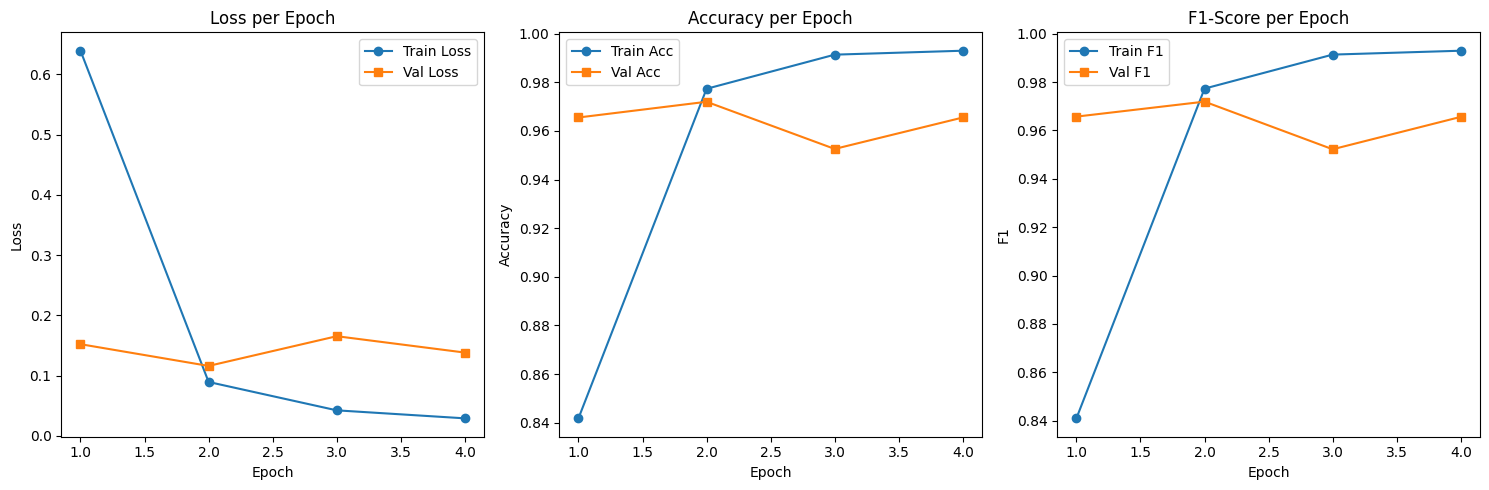

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['train_accuracy'], label='Train Acc', marker='o')
plt.plot(epochs_range, history['val_accuracy'], label='Val Acc', marker='s')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['train_f1'], label='Train F1', marker='o')
plt.plot(epochs_range, history['val_f1'], label='Val F1', marker='s')
plt.title('F1-Score per Epoch')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()

plt.tight_layout()
plt.show()

### תוצאות ה־Fine-Tuning

מודל ה־DistilBERT שעבר Fine-Tuning השיג ביצועים מצוינים על קבוצת הוולידציה, עם Accuracy של כ־97.63% ו־Weighted F1-Score של כ־97.63%.

במהלך תהליך האימון נצפה שיפור עקבי בביצועי המודל לאורך ה־Epochs. ערכי ה־Loss ירדו בהדרגה, בעוד שמדדי ה־Accuracy וה־F1 עלו באופן עקבי הן בקבוצת האימון והן בקבוצת הוולידציה.

בנוסף, נעשה שימוש במנגנון Early Stopping אשר עקב אחר ביצועי המודל על קבוצת הוולידציה ושמר את הגרסה בעלת ביצועי ה־F1 הטובים ביותר. גישה זו סייעה למנוע אימון יתר (Overfitting) ולהבטיח שהמודל הסופי יהיה בעל יכולת הכללה גבוהה גם על נתונים שלא הופיעו במהלך האימון.

תוצאות אלו מצביעות על כך שתהליך ה־Fine-Tuning אפשר למודל ללמוד בצורה יעילה את המאפיינים הייחודיים של פניות הלקוחות בתחום הבנקאות, והפך את DistilBERT למודל בעל הביצועים הטובים ביותר בפרויקט.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# שמירה לתיקייה בדרייב
saved_model_path = "/content/drive/MyDrive/banking77_model"
model.save_pretrained(saved_model_path)
tokenizer.save_pretrained(saved_model_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


('/content/drive/MyDrive/banking77_model/tokenizer_config.json',
 '/content/drive/MyDrive/banking77_model/special_tokens_map.json',
 '/content/drive/MyDrive/banking77_model/vocab.txt',
 '/content/drive/MyDrive/banking77_model/added_tokens.json',
 '/content/drive/MyDrive/banking77_model/tokenizer.json')